In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer

df = pd.read_parquet("experiments/raw/Qwen_Qwen2.5-3B-Instruct.parquet")
df.head()

/Users/Xaver.Davey/miniforge3/envs/skd/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model,dataset,language,prompt_id,prompt_text,human_responses,sample_idx,response_text,n_tokens
0,Qwen/Qwen2.5-3B-Instruct,oasst2_prompts,en,0348b67c-4388-4101-b50b-8cb1dd543edb,Give an opening strategy for the United Kingdo...,[Hearts of Iron 4 is a complex and challenging...,0,"In ""Hearts of Iron IV,"" managing the United Ki...",811
1,Qwen/Qwen2.5-3B-Instruct,oasst2_prompts,en,0348b67c-4388-4101-b50b-8cb1dd543edb,Give an opening strategy for the United Kingdo...,[Hearts of Iron 4 is a complex and challenging...,1,"In Hearts of Iron 4, the United Kingdom plays ...",665
2,Qwen/Qwen2.5-3B-Instruct,oasst2_prompts,en,0348b67c-4388-4101-b50b-8cb1dd543edb,Give an opening strategy for the United Kingdo...,[Hearts of Iron 4 is a complex and challenging...,2,"In Hearts of Iron 4, the United Kingdom is a s...",733
3,Qwen/Qwen2.5-3B-Instruct,oasst2_prompts,en,0348b67c-4388-4101-b50b-8cb1dd543edb,Give an opening strategy for the United Kingdo...,[Hearts of Iron 4 is a complex and challenging...,3,"In Hearts of Iron 4, the United Kingdom (UK) f...",633
4,Qwen/Qwen2.5-3B-Instruct,oasst2_prompts,en,0348b67c-4388-4101-b50b-8cb1dd543edb,Give an opening strategy for the United Kingdo...,[Hearts of Iron 4 is a complex and challenging...,4,"Certainly! ""Hearts of Iron IV"" is a grand stra...",563


In [3]:
enc = SentenceTransformer("intfloat/multilingual-e5-small", device="mps")  # or "cpu" / "cuda"

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10008.59it/s]
BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
texts = ["passage: " + t for t in df.response_text.tolist()]  # e5 requires the prefix
emb = enc.encode(texts, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
# emb.shape == (len(df), 384), L2-normalized → cosine sim = emb @ emb.T 

Batches: 100%|██████████| 305/305 [06:21<00:00,  1.25s/it]


In [5]:
emb

array([[ 0.04422066, -0.03532143, -0.05194042, ...,  0.08285552,
         0.03832767,  0.07981785],
       [ 0.05144843, -0.03340232, -0.03392373, ...,  0.09308238,
         0.03415412,  0.05697011],
       [ 0.05956935, -0.02802495, -0.02113908, ...,  0.07778694,
         0.0130613 ,  0.06555329],
       ...,
       [ 0.02531204, -0.06176219, -0.04654038, ...,  0.02484026,
         0.08248432,  0.04374535],
       [ 0.04279111, -0.04930392, -0.05185246, ...,  0.02164817,
         0.06898317,  0.0501087 ],
       [ 0.0319792 , -0.06552459, -0.05326393, ...,  0.05216349,
         0.07382265,  0.03003598]], shape=(19500, 384), dtype=float32)

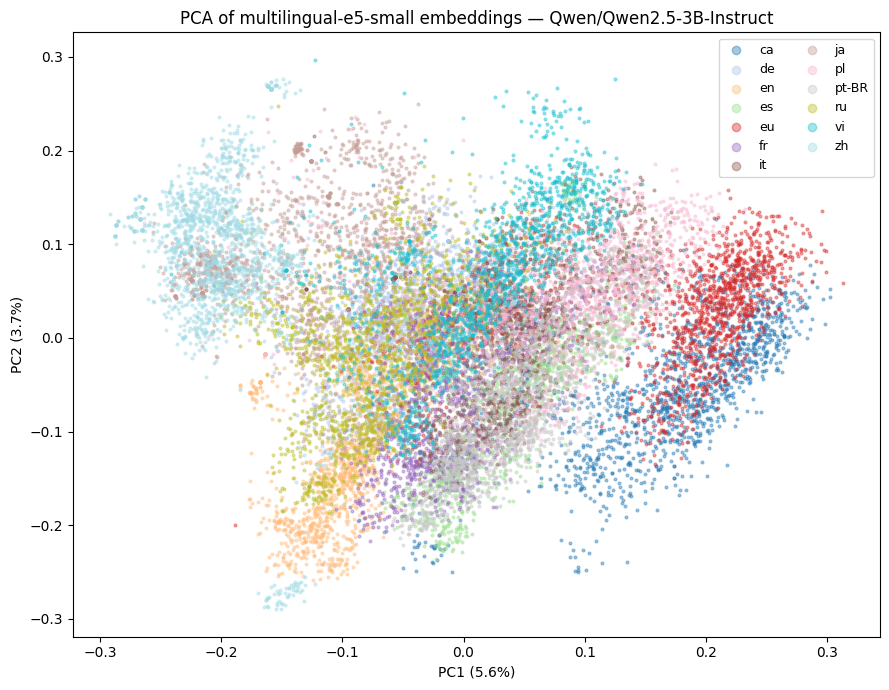

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0).fit(emb)
xy = pca.transform(emb)

fig, ax = plt.subplots(figsize=(9, 7))
langs = sorted(df.language.unique())
cmap = plt.get_cmap("tab20", len(langs))
for i, lang in enumerate(langs):
    m = (df.language == lang).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=4, alpha=0.4, color=cmap(i), label=lang)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"PCA of multilingual-e5-small embeddings — {df.model.iloc[0]}")
ax.legend(markerscale=3, ncols=2, fontsize=9, loc="best")
plt.tight_layout()
plt.show()

Batches: 100%|██████████| 19/19 [00:15<00:00,  1.19it/s]
/var/folders/3c/c4pft9c50g566tkxlyt04r_00000gn/T/ipykernel_44681/3606898060.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(xy_h[hm, 0], xy_h[hm, 1], s=40, marker="x", color=cmap(i),


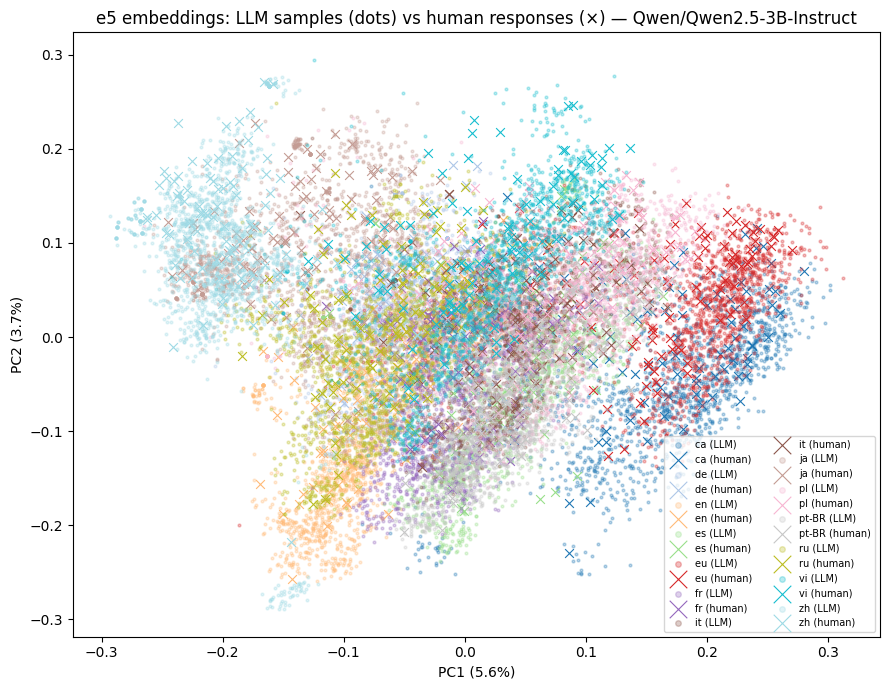

LLM: 19500 embeddings   Human: 1183 embeddings


In [7]:
import numpy as np

# one row per human response (each prompt has a list of them)
prompts = df.drop_duplicates("prompt_id")[["prompt_id", "language", "human_responses"]]
human_df = prompts.explode("human_responses").rename(columns={"human_responses": "response_text"}).reset_index(drop=True)

human_emb = enc.encode(
    ["passage: " + t for t in human_df.response_text.tolist()],
    batch_size=64, normalize_embeddings=True, show_progress_bar=True,
)

# refit PCA on the union so both clouds share the same space
all_emb = np.vstack([emb, human_emb])
pca2 = PCA(n_components=2, random_state=0).fit(all_emb)
xy_m = pca2.transform(emb)
xy_h = pca2.transform(human_emb)

fig, ax = plt.subplots(figsize=(9, 7))
for i, lang in enumerate(langs):
    mm = (df.language == lang).to_numpy()
    hm = (human_df.language == lang).to_numpy()
    ax.scatter(xy_m[mm, 0], xy_m[mm, 1], s=4, alpha=0.3, color=cmap(i), label=f"{lang} (LLM)")
    ax.scatter(xy_h[hm, 0], xy_h[hm, 1], s=40, marker="x", color=cmap(i),
               edgecolors="black", linewidths=0.8, label=f"{lang} (human)")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"e5 embeddings: LLM samples (dots) vs human responses (×) — {df.model.iloc[0]}")
ax.legend(markerscale=2, ncols=2, fontsize=7, loc="best")
plt.tight_layout()
plt.show()
print(f"LLM: {len(emb)} embeddings   Human: {len(human_emb)} embeddings")

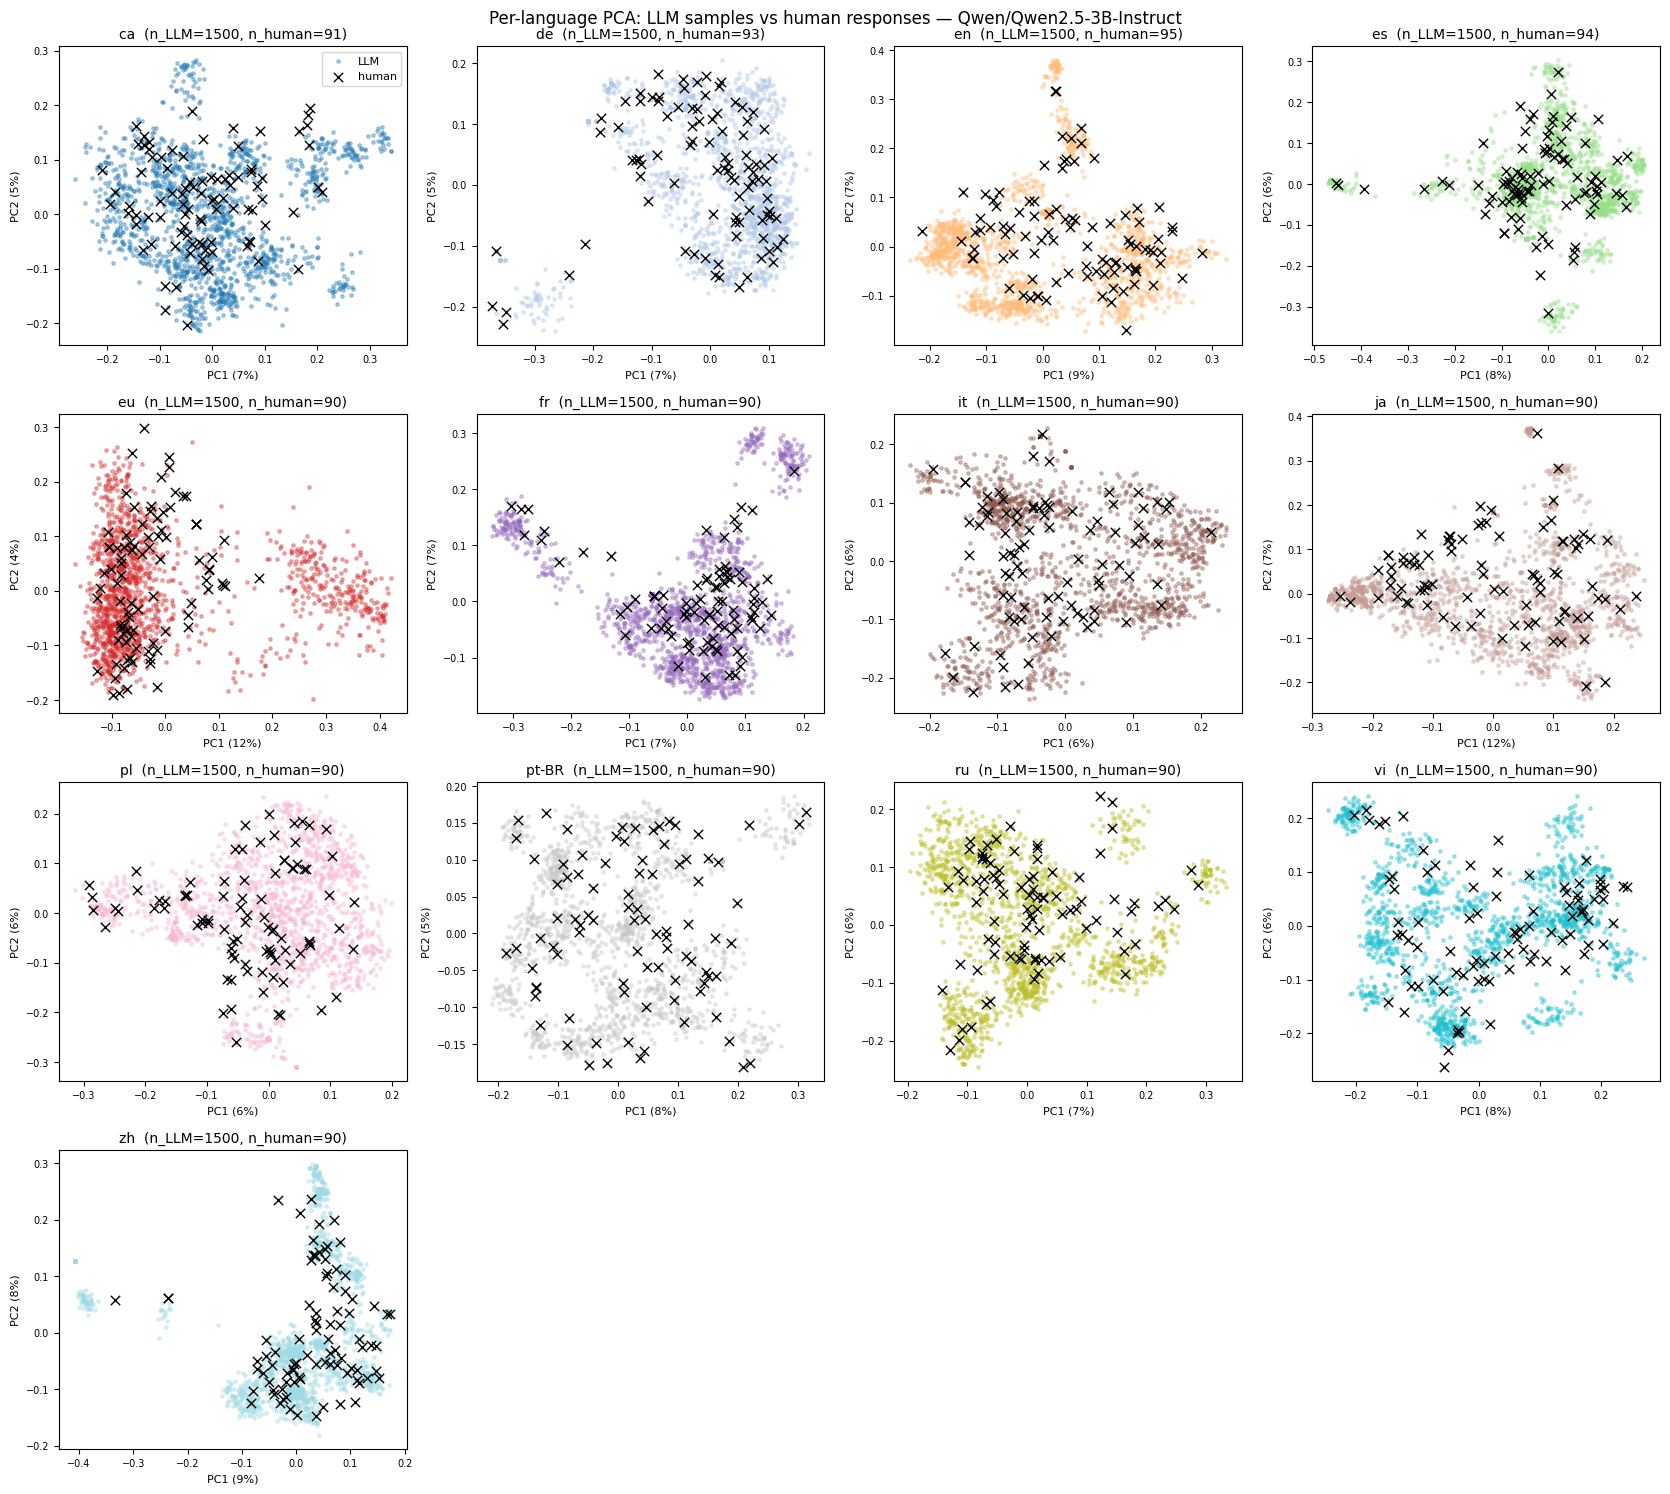

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

langs = sorted(df.language.unique())
cmap = plt.get_cmap("tab20", len(langs))

ncols = 4
nrows = math.ceil(len(langs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
axes = axes.flatten()

for i, lang in enumerate(langs):
    ax = axes[i]
    mm = (df.language == lang).to_numpy()
    hm = (human_df.language == lang).to_numpy()

    lang_emb = np.vstack([emb[mm], human_emb[hm]])
    pca_l = PCA(n_components=2, random_state=0).fit(lang_emb)
    xy_lm = pca_l.transform(emb[mm])
    xy_lh = pca_l.transform(human_emb[hm])

    ax.scatter(xy_lm[:, 0], xy_lm[:, 1], s=6, alpha=0.35, color=cmap(i), label="LLM")
    ax.scatter(xy_lh[:, 0], xy_lh[:, 1], s=45, marker="x", color="black", linewidths=1.0, label="human")
    ax.set_title(f"{lang}  (n_LLM={mm.sum()}, n_human={hm.sum()})", fontsize=10)
    ax.set_xlabel(f"PC1 ({pca_l.explained_variance_ratio_[0]:.0%})", fontsize=8)
    ax.set_ylabel(f"PC2 ({pca_l.explained_variance_ratio_[1]:.0%})", fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8, loc="best")

for j in range(len(langs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Per-language PCA: LLM samples vs human responses — {df.model.iloc[0]}", fontsize=12)
plt.tight_layout()
plt.show()

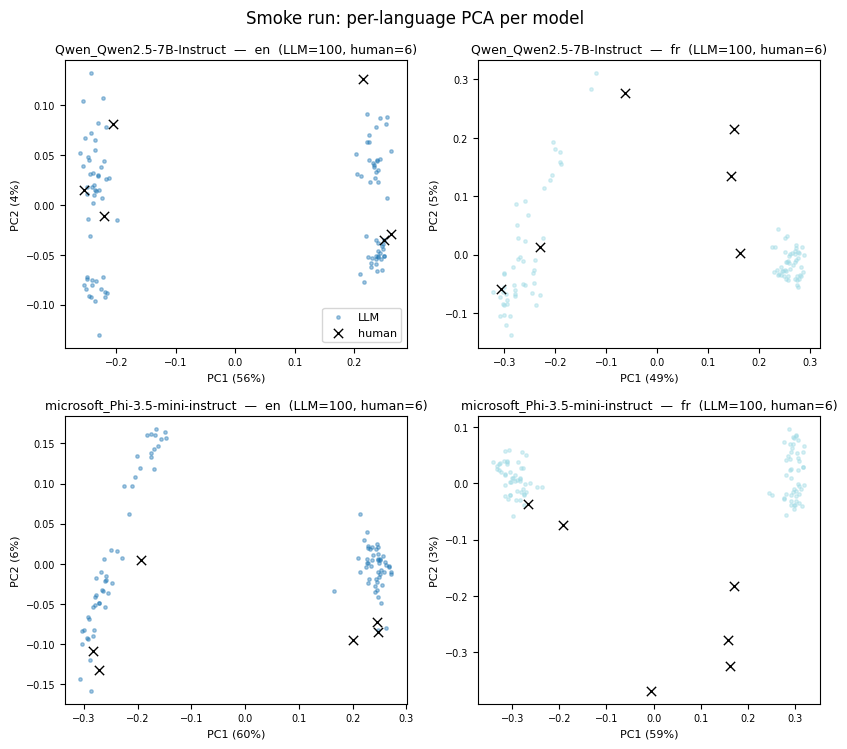

In [9]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Smoke set: 4 prompts (2 en + 2 fr) × 50 samples per model. Per-language PCA,
# LLM samples vs human responses, one row per model.

smoke_files = sorted(Path("experiments/raw_smoke").glob("*.parquet"))
models_dfs = [(p.stem, pd.read_parquet(p)) for p in smoke_files]
langs_sm = sorted({l for _, d in models_dfs for l in d.language.unique()})
cmap_sm = plt.get_cmap("tab20", max(len(langs_sm), 2))

ncols = len(langs_sm)
nrows = len(models_dfs)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows), squeeze=False)

for r, (name, d) in enumerate(models_dfs):
    llm_emb = enc.encode(["passage: " + t for t in d.response_text.tolist()],
                         batch_size=64, normalize_embeddings=True, show_progress_bar=False)
    prompts_sm = d.drop_duplicates("prompt_id")[["prompt_id", "language", "human_responses"]]
    h_df = prompts_sm.explode("human_responses").rename(columns={"human_responses": "response_text"}).reset_index(drop=True)
    h_emb = enc.encode(["passage: " + t for t in h_df.response_text.tolist()],
                       batch_size=64, normalize_embeddings=True, show_progress_bar=False)

    for c, lang in enumerate(langs_sm):
        ax = axes[r, c]
        mm = (d.language == lang).to_numpy()
        hm = (h_df.language == lang).to_numpy()
        if mm.sum() == 0:
            ax.set_visible(False)
            continue
        lang_emb = np.vstack([llm_emb[mm], h_emb[hm]])
        pca_l = PCA(n_components=2, random_state=0).fit(lang_emb)
        xy_lm = pca_l.transform(llm_emb[mm])
        xy_lh = pca_l.transform(h_emb[hm])
        ax.scatter(xy_lm[:, 0], xy_lm[:, 1], s=6, alpha=0.4, color=cmap_sm(c), label="LLM")
        ax.scatter(xy_lh[:, 0], xy_lh[:, 1], s=45, marker="x", color="black", linewidths=1.0, label="human")
        ax.set_title(f"{name}  —  {lang}  (LLM={mm.sum()}, human={hm.sum()})", fontsize=9)
        ax.set_xlabel(f"PC1 ({pca_l.explained_variance_ratio_[0]:.0%})", fontsize=8)
        ax.set_ylabel(f"PC2 ({pca_l.explained_variance_ratio_[1]:.0%})", fontsize=8)
        ax.tick_params(labelsize=7)
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc="best")

fig.suptitle("Smoke run: per-language PCA per model", fontsize=12)
plt.tight_layout()
plt.show()